In [1]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
zh_result='zh_eval_score.txt'
en_result='en_eval_score.txt'
column_name=['variant','audio_file','flag','source','label','score']
zh_df=pd.read_csv(zh_result,delimiter=' ',names=column_name)
en_df=pd.read_csv(en_result,delimiter=' ',names=column_name)
print(zh_df.head())
print(en_df.head())

        variant                  audio_file    flag      source     label  \
0  gaussadded15  gaussadded15/zh/audio1.wav  random        real  bonafide   
1  gaussadded15  gaussadded15/zh/audio2.wav  random        real  bonafide   
2  gaussadded15  gaussadded15/zh/audio3.wav  random  GPT_SoVITS     spoof   
3  gaussadded15  gaussadded15/zh/audio4.wav  random  voicemaker     spoof   
4  gaussadded15  gaussadded15/zh/audio5.wav  random     xtts_v2     spoof   

      score  
0  5.396986  
1 -0.180349  
2  1.059019  
3  1.862164  
4  8.272525  
        variant                  audio_file    flag      source     label  \
0  gaussadded15  gaussadded15/en/audio1.wav  random     StarGan     spoof   
1  gaussadded15  gaussadded15/en/audio2.wav  random   OpenVoice     spoof   
2  gaussadded15  gaussadded15/en/audio3.wav  random        real  bonafide   
3  gaussadded15  gaussadded15/en/audio4.wav  random        real  bonafide   
4  gaussadded15  gaussadded15/en/audio5.wav  random  DiffHiervc     

中文数据集的EER: 0.29993252361673417, AUC: 0.7181683905698794, EER阈值: -1.7763508558273315
英文数据集的EER: 0.2792533936651584, AUC: 0.7329159698477373, EER阈值: -0.3368688821792602
-0.02067912995157578


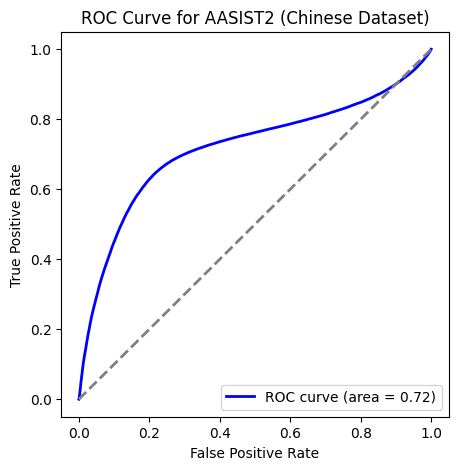

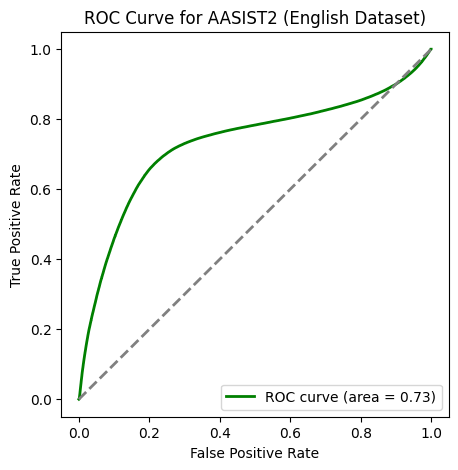

In [3]:

zh_labels = zh_df['label'].apply(lambda x: 1 if x == 'bonafide' else 0)
zh_scores = zh_df['score']
en_labels = en_df['label'].apply(lambda x: 1 if x == 'bonafide' else 0)
en_scores = en_df['score']

# 计算TPR和FPR
fpr_zh, tpr_zh, thresholds_zh = roc_curve(zh_labels, zh_scores)
fpr_en, tpr_en, thresholds_en = roc_curve(en_labels, en_scores)

# 计算EER并找到对应的阈值
def compute_eer(fpr, tpr, thresholds):
    eer_index = np.nanargmin(np.abs(fpr - (1 - tpr)))
    eer = fpr[eer_index]
    eer_threshold = thresholds[eer_index]
    return eer, eer_threshold

eer_zh, eer_threshold_zh = compute_eer(fpr_zh, tpr_zh, thresholds_zh)
eer_en, eer_threshold_en = compute_eer(fpr_en, tpr_en, thresholds_en)

# 计算AUC分数
auc_zh = auc(fpr_zh, tpr_zh)
auc_en = auc(fpr_en, tpr_en)

print(f"中文数据集的EER: {eer_zh}, AUC: {auc_zh}, EER阈值: {eer_threshold_zh}")
print(f"英文数据集的EER: {eer_en}, AUC: {auc_en}, EER阈值: {eer_threshold_en}")
print(eer_en-eer_zh)

plt.figure(figsize=(5, 5))
plt.plot(fpr_zh, tpr_zh, color='blue', lw=2, label=f'ROC curve (area = {auc_zh:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for AASIST2 (Chinese Dataset)')
plt.legend(loc="lower right")
plt.show()

# 英文数据集的ROC曲线
plt.figure(figsize=(5, 5))
plt.plot(fpr_en, tpr_en, color='green', lw=2, label=f'ROC curve (area = {auc_en:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for AASIST2 (English Dataset)')
plt.legend(loc="lower right")
plt.show()

In [4]:
zh_df['eva_label'] = zh_df['score'].apply(lambda x: 1 if x >= eer_threshold_zh else 0)
en_df['eva_label'] = en_df['score'].apply(lambda x: 1 if x >= eer_threshold_en else 0)
# zh_df['variant']=zh_df['audio_file'].apply(lambda x: x.split('/')[0])
# en_df['variant']=en_df['audio_file'].apply(lambda x: x.split('/')[0])
print(zh_df.head())
print(en_df.head())

        variant                  audio_file    flag      source     label  \
0  gaussadded15  gaussadded15/zh/audio1.wav  random        real  bonafide   
1  gaussadded15  gaussadded15/zh/audio2.wav  random        real  bonafide   
2  gaussadded15  gaussadded15/zh/audio3.wav  random  GPT_SoVITS     spoof   
3  gaussadded15  gaussadded15/zh/audio4.wav  random  voicemaker     spoof   
4  gaussadded15  gaussadded15/zh/audio5.wav  random     xtts_v2     spoof   

      score  eva_label  
0  5.396986          1  
1 -0.180349          1  
2  1.059019          1  
3  1.862164          1  
4  8.272525          1  
        variant                  audio_file    flag      source     label  \
0  gaussadded15  gaussadded15/en/audio1.wav  random     StarGan     spoof   
1  gaussadded15  gaussadded15/en/audio2.wav  random   OpenVoice     spoof   
2  gaussadded15  gaussadded15/en/audio3.wav  random        real  bonafide   
3  gaussadded15  gaussadded15/en/audio4.wav  random        real  bonafide   
4 

In [6]:
def compute_far(group, eer_threshold):
    false_accepts = ((group['score'] >= eer_threshold) & (group['label'] == 'spoof')).sum()
    total_negatives = (group['label'] == 'spoof').sum()
    far = false_accepts / total_negatives if total_negatives > 0 else 0
    return far
# 按variant分组并计算FAR
zh_far_by_variant = zh_df.groupby('variant').apply(lambda group: compute_far(group, eer_threshold_zh)).reset_index(name='FAR')
en_far_by_variant = en_df.groupby('variant').apply(lambda group: compute_far(group, eer_threshold_en)).reset_index(name='FAR')

# 输出结果
print("中文数据集的FAR:")
print(zh_far_by_variant)
print("英文数据集的FAR:")
print(en_far_by_variant)

中文数据集的FAR:
                  variant       FAR
0              Alldataset  0.314737
1           Alldataset32K  0.229474
2           Alldataset44k  0.212632
3     NoiseAdded-animal15  0.133684
4     NoiseAdded-animal20  0.181053
5     NoiseAdded-animal25  0.235263
6   NoiseAdded-exterior15  0.151579
7   NoiseAdded-exterior20  0.193947
8   NoiseAdded-exterior25  0.217105
9      NoiseAdded-human15  0.071579
10     NoiseAdded-human20  0.096842
11     NoiseAdded-human25  0.126579
12  NoiseAdded-interior15  0.085526
13  NoiseAdded-interior20  0.100000
14  NoiseAdded-interior25  0.135263
15   NoiseAdded-natural15  0.051053
16   NoiseAdded-natural20  0.080000
17   NoiseAdded-natural25  0.102632
18          Re-Alldataset  0.995263
19         TimeScaling105  0.307632
20         TimeScaling110  0.316579
21          TimeScaling90  0.387895
22          TimeScaling95  0.348684
23              expfade10  0.207632
24              expfade20  0.237368
25              expfade30  0.280526
26           gaus

/tmp/ipykernel_2191257/666044659.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zh_far_by_variant = zh_df.groupby('variant').apply(lambda group: compute_far(group, eer_threshold_zh)).reset_index(name='FAR')
/tmp/ipykernel_2191257/666044659.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  en_far_by_variant = en_df.groupby('variant').apply(lambda group: compute_far(group, eer_threshold_en)).reset_inde

In [7]:
# 按variant和flag分组并计算FAR
zh_far_by_variant_flag = zh_df.groupby(['variant', 'flag']).apply(lambda group: compute_far(group, eer_threshold_zh)).reset_index(name='FAR')
en_far_by_variant_flag = en_df.groupby(['variant', 'flag']).apply(lambda group: compute_far(group, eer_threshold_en)).reset_index(name='FAR')


# 输出结果
print("中文数据集的FAR:")
print(zh_far_by_variant_flag.to_string(index=False))
print("英文数据集的FAR:")
print(en_far_by_variant_flag.to_string(index=False))

中文数据集的FAR:
              variant   flag      FAR
           Alldataset    fix 0.294211
           Alldataset random 0.335263
        Alldataset32K    fix 0.186316
        Alldataset32K random 0.272632
        Alldataset44k    fix 0.170000
        Alldataset44k random 0.255263
  NoiseAdded-animal15    fix 0.130526
  NoiseAdded-animal15 random 0.136842
  NoiseAdded-animal20    fix 0.176316
  NoiseAdded-animal20 random 0.185789
  NoiseAdded-animal25    fix 0.208947
  NoiseAdded-animal25 random 0.261579
NoiseAdded-exterior15    fix 0.140000
NoiseAdded-exterior15 random 0.163158
NoiseAdded-exterior20    fix 0.185263
NoiseAdded-exterior20 random 0.202632
NoiseAdded-exterior25    fix 0.206842
NoiseAdded-exterior25 random 0.227368
   NoiseAdded-human15    fix 0.071579
   NoiseAdded-human15 random 0.071579
   NoiseAdded-human20    fix 0.088947
   NoiseAdded-human20 random 0.104737
   NoiseAdded-human25    fix 0.103158
   NoiseAdded-human25 random 0.150000
NoiseAdded-interior15    fix 0.077368
N

/tmp/ipykernel_2191257/563364231.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zh_far_by_variant_flag = zh_df.groupby(['variant', 'flag']).apply(lambda group: compute_far(group, eer_threshold_zh)).reset_index(name='FAR')
/tmp/ipykernel_2191257/563364231.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  en_far_by_variant_flag = en_df.groupby(['variant', 'flag']).apply(lambda group: compute_far(group,

In [8]:
# 按variant和flag分组并计算FAR
zh_far_by_flag = zh_df.groupby('flag').apply(lambda group: compute_far(group, eer_threshold_zh)).reset_index(name='FAR')
en_far_by_flag = en_df.groupby('flag').apply(lambda group: compute_far(group, eer_threshold_en)).reset_index(name='FAR')


# 输出结果
print("中文数据集的FAR:")
print(zh_far_by_flag)
print("英文数据集的FAR:")
print(en_far_by_flag)

中文数据集的FAR:
     flag       FAR
0     fix  0.284318
1  random  0.315547
英文数据集的FAR:
     flag       FAR
0     fix  0.267541
1  random  0.290965


/tmp/ipykernel_2191257/1484334853.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zh_far_by_flag = zh_df.groupby('flag').apply(lambda group: compute_far(group, eer_threshold_zh)).reset_index(name='FAR')
/tmp/ipykernel_2191257/1484334853.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  en_far_by_flag = en_df.groupby('flag').apply(lambda group: compute_far(group, eer_threshold_en)).reset_index(name='FA